Задание Light

Выполните подробную работу с параметрами словаря и формированием гиперпараметров нейронной сети. Создайте 9 нейросетей с различными гиперпараметрами (см. пунтк 2 и 3)

 Для этого необходимо:

  1. Воссоздать ноутбук, аналогичный ноутбуку практической части №1, загрузив при этом необходимую нам базу (код уже доступен в ноутбуке).

  2. Задать в ноутбуке следующие параметры для размера словаря, ширины окна и шага:

    - Размер словаря - от 10000 до 20000 (выбрать меньшее значение диапазона, если будет перегрузка ОЗУ и перезапуск подключения к Colaboratory)
    - Ширина окна - от 1000 до 2000
    - Шаг - от 100 до 500 (на обучение лучше влияет наименьший шаг, но это может перегрузить ОЗУ).

  3. Создать архитектуру сети и задать гиперпараметры. Можно воспользоваться шаблоном:
  
   - Добавьте модель прямого распространения **Sequential()**
   - Добавьте один или несколько полносвязных (**Dense**) слоёв
   - Добавьте слои **Dropout()** и **BatchNormalization()**
   - Добавьте выходной полносвязный слой с количеством нейронов, соответствующим количеству классов (число писателей)
  
   Напомним, что точность сети можно проверить по значению показателя 'val_accuracy' на конце каждой эпохи.
   

In [1]:
# импорт библиотек
import os
import re
import time
import zipfile
import random
import shutil

import gdown
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras import utils
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Dropout, BatchNormalization
from tensorflow.keras.preprocessing.text import Tokenizer
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

%matplotlib inline

# фиксация случайности, чтобы результаты меньше прыгали при повторном запуске
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)


In [2]:
# загрузка и распаковка базы
DATA_URL = 'https://storage.yandexcloud.net/aiueducation/Content/base/l7/writers.zip'
ARCHIVE_NAME = 'writers.zip'
FILE_DIR = 'writers'

# загрузка архива, если его еще нет в папке
if not os.path.exists(ARCHIVE_NAME):
    gdown.download(DATA_URL, ARCHIVE_NAME, quiet=False)
else:
    print('Архив уже загружен:', ARCHIVE_NAME)

# очистка старой папки, чтобы при повторном запуске файлы не смешивались
if os.path.exists(FILE_DIR):
    shutil.rmtree(FILE_DIR)

# распаковка через zipfile вместо команды unzip
with zipfile.ZipFile(ARCHIVE_NAME, 'r') as archive:
    archive.extractall(FILE_DIR)

print('Файлы в папке:')
print(os.listdir(FILE_DIR)[:10])


Downloading...
From: https://storage.yandexcloud.net/aiueducation/Content/base/l7/writers.zip
To: /content/writers.zip
100%|██████████| 8.13M/8.13M [00:01<00:00, 7.38MB/s]


Файлы в папке:
['(Макс Фрай) Обучающая_5 вместе.txt', '(О. Генри) Тестовая_20 вместе.txt', '(Клиффорд_Саймак) Тестовая_2 вместе.txt', '(Булгаков) Тестовая_2 вместе.txt', '(О. Генри) Обучающая_50 вместе.txt', '(Стругацкие) Тестовая_2 вместе.txt', '(Клиффорд_Саймак) Обучающая_5 вместе.txt', '(Рэй Брэдберри) Обучающая_22 вместе.txt', '(Булгаков) Обучающая_5 вместе.txt', '(Стругацкие) Обучающая_5 вместе.txt']


In [3]:
# загрузка текстов писателей
SIG_TRAIN = 'обучающая' # признак обучающей выборки в названии файла
SIG_TEST = 'тестовая'   # признак тестовой выборки в названии файла

CLASS_LIST = []
text_train = []
text_test = []

# чтение файла с запасным вариантом кодировки
def read_text(path):
    try:
        with open(path, 'r', encoding='utf-8') as f:
            return f.read()
    except UnicodeDecodeError:
        with open(path, 'r', encoding='cp1251', errors='ignore') as f:
            return f.read()

# сортировка нужна, чтобы порядок классов был стабильным
for file_name in sorted(os.listdir(FILE_DIR)):
    # выделение автора и типа выборки из имени файла
    match = re.match(r'\((.+)\)\s+(\S+)_', file_name)

    if match is None:
        continue

    class_name = match.group(1)
    subset_name = match.group(2).lower()

    is_train = SIG_TRAIN in subset_name
    is_test = SIG_TEST in subset_name

    if not (is_train or is_test):
        continue

    if class_name not in CLASS_LIST:
        CLASS_LIST.append(class_name)
        text_train.append('')
        text_test.append('')
        print(f'добавление класса: {class_name}')

    class_index = CLASS_LIST.index(class_name)
    file_path = os.path.join(FILE_DIR, file_name)
    text = read_text(file_path).replace('\n', ' ')

    if is_train:
        text_train[class_index] += ' ' + text
    else:
        text_test[class_index] += ' ' + text

CLASS_COUNT = len(CLASS_LIST)

print('Количество классов:', CLASS_COUNT)
print('Классы:', CLASS_LIST)
print('Длина обучающих текстов:', [len(text) for text in text_train])
print('Длина проверочных текстов:', [len(text) for text in text_test])


добавление класса: Булгаков
добавление класса: Клиффорд_Саймак
добавление класса: Макс Фрай
добавление класса: О. Генри
добавление класса: Рэй Брэдберри
добавление класса: Стругацкие
Количество классов: 6
Классы: ['Булгаков', 'Клиффорд_Саймак', 'Макс Фрай', 'О. Генри', 'Рэй Брэдберри', 'Стругацкие']
Длина обучающих текстов: [1765649, 1609508, 3700011, 1049518, 1386455, 2042470]
Длина проверочных текстов: [875043, 318812, 1278192, 349663, 868674, 704847]


In [4]:
# класс подготовки данных
class DataProcessor:
    def __init__(self, vocab_size, win_size, win_hop):
        self.vocab_size = vocab_size # размер словаря
        self.win_size = win_size     # ширина окна
        self.win_hop = win_hop       # шаг окна
        self.tokenizer = None        # токенизатор

    # нарезка последовательности на окна
    def make_windows(self, sequence):
        windows = []

        for start in range(0, len(sequence) - self.win_size + 1, self.win_hop):
            windows.append(sequence[start:start + self.win_size])

        # защита от пустой выборки, если текст оказался короче окна
        if len(windows) == 0 and len(sequence) > 0:
            windows.append(sequence)

        return windows

    # создание примеров и правильных ответов
    def vectorize_sequence(self, sequences):
        x_data = []
        y_data = []
        class_count = len(sequences)

        for class_index, sequence in enumerate(sequences):
            windows = self.make_windows(sequence)
            x_data.extend(windows)
            y_data.extend([utils.to_categorical(class_index, class_count)] * len(windows))

        return np.array(x_data, dtype=object), np.array(y_data, dtype='float32')

    # полная подготовка обучающей и проверочной выборки
    def prepare(self, train_texts, test_texts):
        self.tokenizer = Tokenizer(
            num_words=self.vocab_size,
            filters='!"#$%&()*+,-./:;<=>?@[\\]^_`{|}~\t\n\xa0',
            lower=True,
            split=' ',
            oov_token='unknown',
            char_level=False
        )

        self.tokenizer.fit_on_texts(train_texts)

        train_sequences = self.tokenizer.texts_to_sequences(train_texts)
        test_sequences = self.tokenizer.texts_to_sequences(test_texts)

        x_train, y_train = self.vectorize_sequence(train_sequences)
        x_test, y_test = self.vectorize_sequence(test_sequences)

        # bag of words
        x_train_bow = self.tokenizer.sequences_to_matrix(x_train.tolist(), mode='binary').astype('float32')
        x_test_bow = self.tokenizer.sequences_to_matrix(x_test.tolist(), mode='binary').astype('float32')

        print('VOCAB_SIZE:', self.vocab_size)
        print('WIN_SIZE:', self.win_size)
        print('WIN_HOP:', self.win_hop)
        print('x_train_bow:', x_train_bow.shape)
        print('y_train:', y_train.shape)
        print('x_test_bow:', x_test_bow.shape)
        print('y_test:', y_test.shape)

        return x_train_bow, y_train, x_test_bow, y_test


# создание модели
def create_model(input_dim, class_count):
    model = Sequential(name='writer_classifier')

    model.add(Input(shape=(input_dim,)))

    model.add(Dense(256, activation='relu'))
    model.add(BatchNormalization())
    model.add(Dropout(0.3))

    model.add(Dense(128, activation='relu'))
    model.add(BatchNormalization())
    model.add(Dropout(0.3))

    model.add(Dense(class_count, activation='softmax'))

    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model


# график обучения одной модели
def plot_history(history, vocab_size, win_size, win_hop):
    epochs = range(1, len(history.history['accuracy']) + 1)

    plt.figure(figsize=(14, 5))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, history.history['accuracy'], label='точность обучения')
    plt.plot(epochs, history.history['val_accuracy'], label='точность проверки')
    plt.title(f'точность: словарь={vocab_size}, окно={win_size}, шаг={win_hop}')
    plt.xlabel('эпоха')
    plt.ylabel('точность')
    plt.grid(True)
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs, history.history['loss'], label='ошибка обучения')
    plt.plot(epochs, history.history['val_loss'], label='ошибка проверки')
    plt.title(f'ошибка: словарь={vocab_size}, окно={win_size}, шаг={win_hop}')
    plt.xlabel('эпоха')
    plt.ylabel('ошибка')
    plt.grid(True)
    plt.legend()

    plt.show()


# запуск одного опыта
def run_experiment(vocab_size, win_size, win_hop, epochs=12, batch_size=128):
    tf.keras.backend.clear_session()

    processor = DataProcessor(vocab_size, win_size, win_hop)
    x_train_bow, y_train, x_test_bow, y_test = processor.prepare(text_train, text_test)

    model = create_model(
        input_dim=x_train_bow.shape[1],
        class_count=len(CLASS_LIST)
    )

    history = model.fit(
        x_train_bow,
        y_train,
        epochs=epochs,
        batch_size=batch_size,
        validation_data=(x_test_bow, y_test),
        verbose=1
    )

    plot_history(history, vocab_size, win_size, win_hop)

    result = {
        'VOCAB_SIZE': vocab_size,
        'WIN_SIZE': win_size,
        'WIN_HOP': win_hop,
        'Точность на обучении': history.history['accuracy'][-1],
        'Точность на проверке': history.history['val_accuracy'][-1],
        'Лучшая точность на проверке': max(history.history['val_accuracy']),
        'Ошибка на обучении': history.history['loss'][-1],
        'Ошибка на проверке': history.history['val_loss'][-1],
        'Лучшая ошибка на проверке': min(history.history['val_loss'])
    }

    return result, history



модель 1 из 9
словарь=10000, окно=1000, шаг=100
VOCAB_SIZE: 10000
WIN_SIZE: 1000
WIN_HOP: 100
x_train_bow: (18508, 10000)
y_train: (18508, 6)
x_test_bow: (7031, 10000)
y_test: (7031, 6)
Epoch 1/12
145/145 ━━━━━━━━━━━━━━━━━━━━ 11s 42ms/step - accuracy: 0.9699 - loss: 0.1004 - val_accuracy: 0.8673 - val_loss: 0.4662
Epoch 2/12
145/145 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 1.0000 - loss: 0.0018 - val_accuracy: 0.8912 - val_loss: 0.3412
Epoch 3/12
145/145 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 1.0000 - loss: 8.6142e-04 - val_accuracy: 0.8940 - val_loss: 0.3165
Epoch 4/12
145/145 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 1.0000 - loss: 5.3670e-04 - val_accuracy: 0.8952 - val_loss: 0.3113
Epoch 5/12
145/145 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 1.0000 - loss: 3.7855e-04 - val_accuracy: 0.8966 - val_loss: 0.3084
Epoch 6/12
145/145 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 1.0000 - loss: 2.6626e-04 - val_accuracy: 0.8963 - val_loss: 0.3087
Epoch 7/12
145/145 ━━━━━━━━

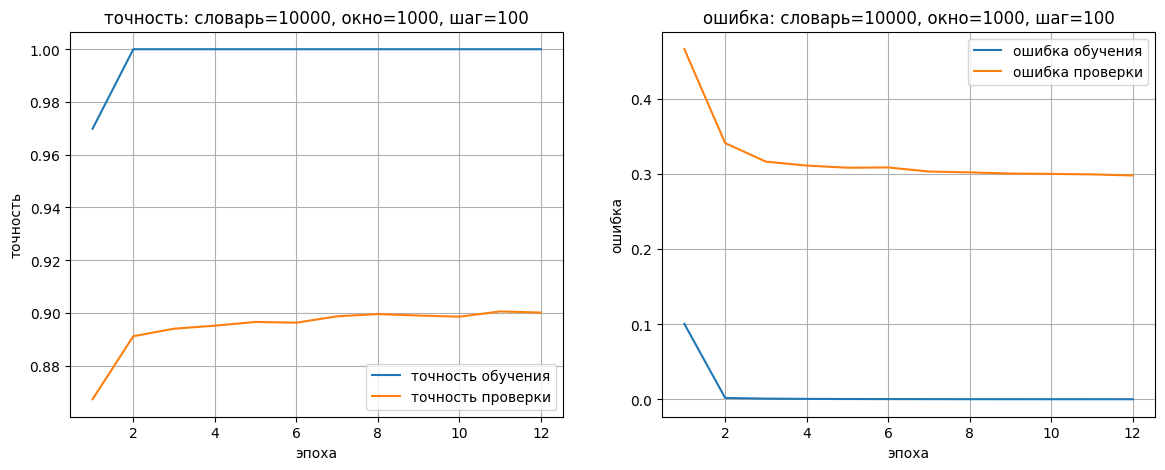


модель 2 из 9
словарь=10000, окно=1500, шаг=250
VOCAB_SIZE: 10000
WIN_SIZE: 1500
WIN_HOP: 250
x_train_bow: (7391, 10000)
y_train: (7391, 6)
x_test_bow: (2802, 10000)
y_test: (2802, 6)
Epoch 1/12
58/58 ━━━━━━━━━━━━━━━━━━━━ 10s 92ms/step - accuracy: 0.9483 - loss: 0.1694 - val_accuracy: 0.7366 - val_loss: 0.7347
Epoch 2/12
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 1.0000 - loss: 0.0040 - val_accuracy: 0.8544 - val_loss: 0.4712
Epoch 3/12
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 1.0000 - loss: 0.0021 - val_accuracy: 0.9029 - val_loss: 0.3489
Epoch 4/12
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 1.0000 - loss: 0.0015 - val_accuracy: 0.9115 - val_loss: 0.3028
Epoch 5/12
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 1.0000 - loss: 0.0010 - val_accuracy: 0.9168 - val_loss: 0.2806
Epoch 6/12
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 1.0000 - loss: 8.1339e-04 - val_accuracy: 0.9172 - val_loss: 0.2703
Epoch 7/12
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - a

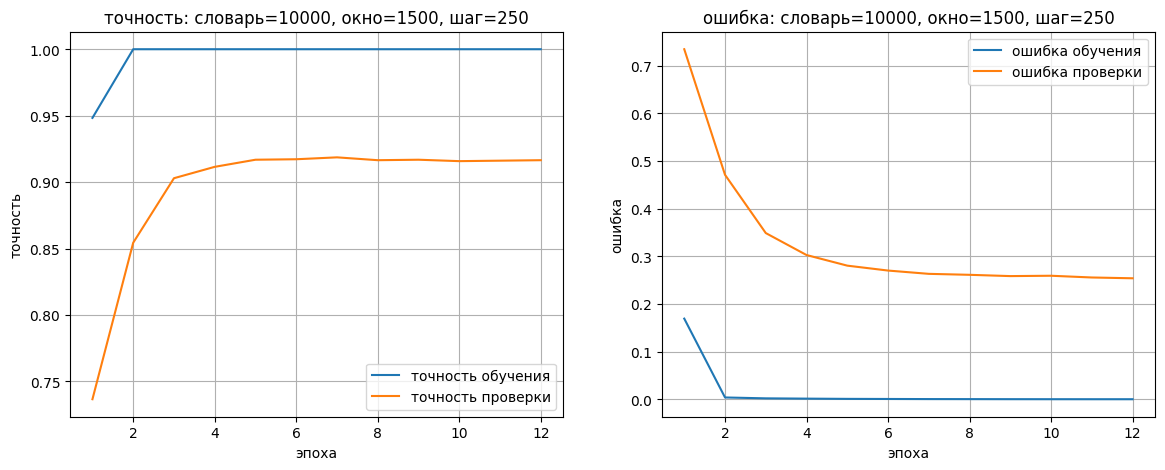


модель 3 из 9
словарь=10000, окно=2000, шаг=500
VOCAB_SIZE: 10000
WIN_SIZE: 2000
WIN_HOP: 500
x_train_bow: (3691, 10000)
y_train: (3691, 6)
x_test_bow: (1396, 10000)
y_test: (1396, 6)
Epoch 1/12
29/29 ━━━━━━━━━━━━━━━━━━━━ 9s 146ms/step - accuracy: 0.9044 - loss: 0.3102 - val_accuracy: 0.8331 - val_loss: 0.6871
Epoch 2/12
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 1.0000 - loss: 0.0085 - val_accuracy: 0.8868 - val_loss: 0.5168
Epoch 3/12
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 1.0000 - loss: 0.0042 - val_accuracy: 0.8997 - val_loss: 0.4431
Epoch 4/12
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 1.0000 - loss: 0.0028 - val_accuracy: 0.9062 - val_loss: 0.3961
Epoch 5/12
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 1.0000 - loss: 0.0021 - val_accuracy: 0.9126 - val_loss: 0.3638
Epoch 6/12
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 1.0000 - loss: 0.0016 - val_accuracy: 0.9148 - val_loss: 0.3430
Epoch 7/12
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step -

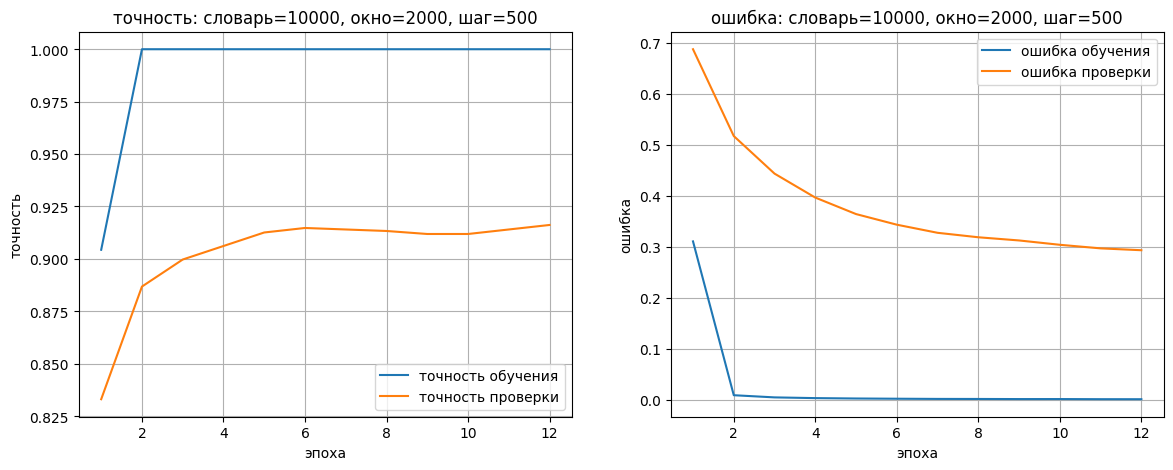


модель 4 из 9
словарь=15000, окно=1000, шаг=100
VOCAB_SIZE: 15000
WIN_SIZE: 1000
WIN_HOP: 100
x_train_bow: (18508, 15000)
y_train: (18508, 6)
x_test_bow: (7031, 15000)
y_test: (7031, 6)
Epoch 1/12
145/145 ━━━━━━━━━━━━━━━━━━━━ 11s 40ms/step - accuracy: 0.9755 - loss: 0.0827 - val_accuracy: 0.8573 - val_loss: 0.5077
Epoch 2/12
145/145 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 1.0000 - loss: 0.0015 - val_accuracy: 0.8825 - val_loss: 0.3773
Epoch 3/12
145/145 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 1.0000 - loss: 6.9072e-04 - val_accuracy: 0.8865 - val_loss: 0.3497
Epoch 4/12
145/145 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 1.0000 - loss: 4.1662e-04 - val_accuracy: 0.8868 - val_loss: 0.3417
Epoch 5/12
145/145 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 1.0000 - loss: 3.0193e-04 - val_accuracy: 0.8898 - val_loss: 0.3331
Epoch 6/12
145/145 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 1.0000 - loss: 2.1675e-04 - val_accuracy: 0.8892 - val_loss: 0.3330
Epoch 7/12
145/145 ━━━

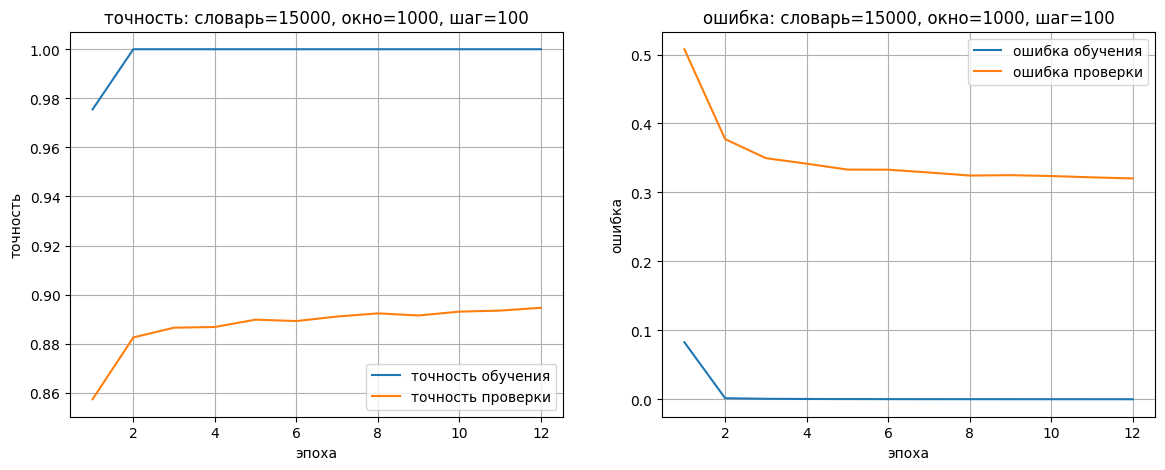


модель 5 из 9
словарь=15000, окно=1500, шаг=250
VOCAB_SIZE: 15000
WIN_SIZE: 1500
WIN_HOP: 250
x_train_bow: (7391, 15000)
y_train: (7391, 6)
x_test_bow: (2802, 15000)
y_test: (2802, 6)
Epoch 1/12
58/58 ━━━━━━━━━━━━━━━━━━━━ 9s 77ms/step - accuracy: 0.9547 - loss: 0.1557 - val_accuracy: 0.7570 - val_loss: 0.7606
Epoch 2/12
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9999 - loss: 0.0034 - val_accuracy: 0.8590 - val_loss: 0.4691
Epoch 3/12
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 1.0000 - loss: 0.0018 - val_accuracy: 0.9051 - val_loss: 0.3391
Epoch 4/12
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 1.0000 - loss: 0.0012 - val_accuracy: 0.9243 - val_loss: 0.2841
Epoch 5/12
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 1.0000 - loss: 8.5634e-04 - val_accuracy: 0.9268 - val_loss: 0.2612
Epoch 6/12
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 1.0000 - loss: 6.4048e-04 - val_accuracy: 0.9297 - val_loss: 0.2501
Epoch 7/12
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms

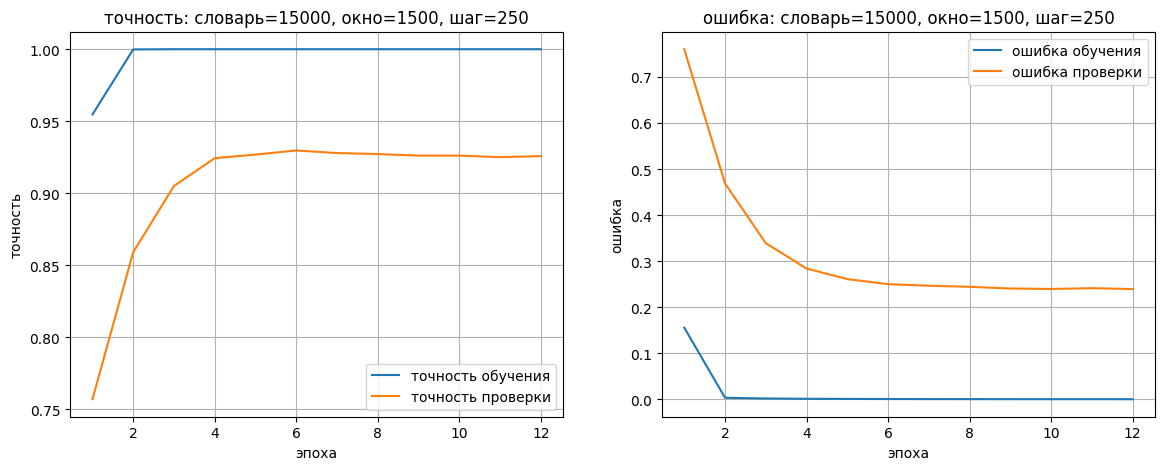


модель 6 из 9
словарь=15000, окно=2000, шаг=500
VOCAB_SIZE: 15000
WIN_SIZE: 2000
WIN_HOP: 500
x_train_bow: (3691, 15000)
y_train: (3691, 6)
x_test_bow: (1396, 15000)
y_test: (1396, 6)
Epoch 1/12
29/29 ━━━━━━━━━━━━━━━━━━━━ 9s 171ms/step - accuracy: 0.9241 - loss: 0.2639 - val_accuracy: 0.6583 - val_loss: 0.8950
Epoch 2/12
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9997 - loss: 0.0070 - val_accuracy: 0.7428 - val_loss: 0.6835
Epoch 3/12
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9997 - loss: 0.0041 - val_accuracy: 0.7987 - val_loss: 0.5879
Epoch 4/12
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 1.0000 - loss: 0.0023 - val_accuracy: 0.8231 - val_loss: 0.5209
Epoch 5/12
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 1.0000 - loss: 0.0020 - val_accuracy: 0.8424 - val_loss: 0.4653
Epoch 6/12
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 1.0000 - loss: 0.0015 - val_accuracy: 0.8625 - val_loss: 0.4187
Epoch 7/12
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step -

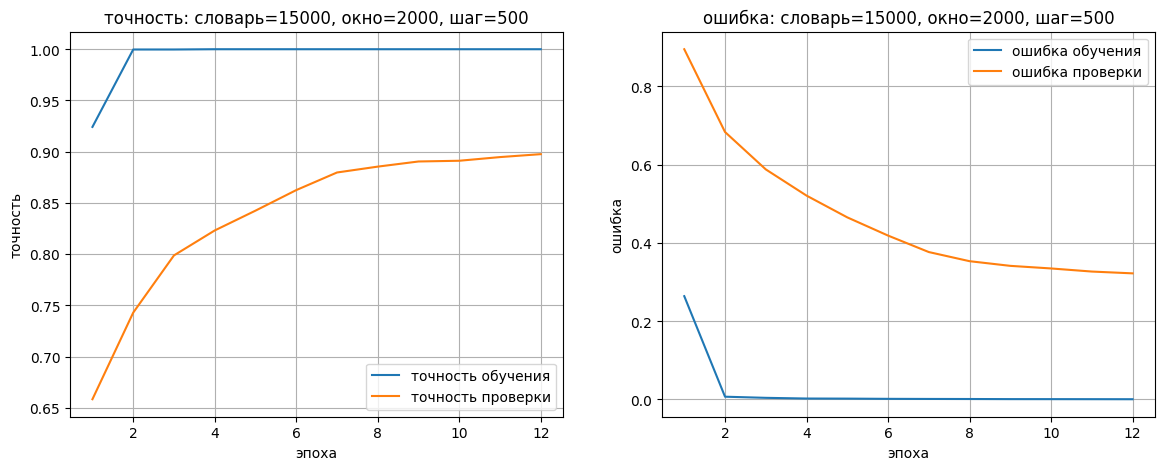


модель 7 из 9
словарь=20000, окно=1000, шаг=100
VOCAB_SIZE: 20000
WIN_SIZE: 1000
WIN_HOP: 100
x_train_bow: (18508, 20000)
y_train: (18508, 6)
x_test_bow: (7031, 20000)
y_test: (7031, 6)
Epoch 1/12
145/145 ━━━━━━━━━━━━━━━━━━━━ 11s 43ms/step - accuracy: 0.9788 - loss: 0.0743 - val_accuracy: 0.8899 - val_loss: 0.4653
Epoch 2/12
145/145 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 1.0000 - loss: 0.0013 - val_accuracy: 0.8949 - val_loss: 0.3625
Epoch 3/12
145/145 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 1.0000 - loss: 6.4838e-04 - val_accuracy: 0.9037 - val_loss: 0.3283
Epoch 4/12
145/145 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 1.0000 - loss: 3.8972e-04 - val_accuracy: 0.9029 - val_loss: 0.3216
Epoch 5/12
145/145 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 1.0000 - loss: 2.8639e-04 - val_accuracy: 0.9026 - val_loss: 0.3202
Epoch 6/12
145/145 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 1.0000 - loss: 2.0153e-04 - val_accuracy: 0.9041 - val_loss: 0.3150
Epoch 7/12
145/145 ━━━

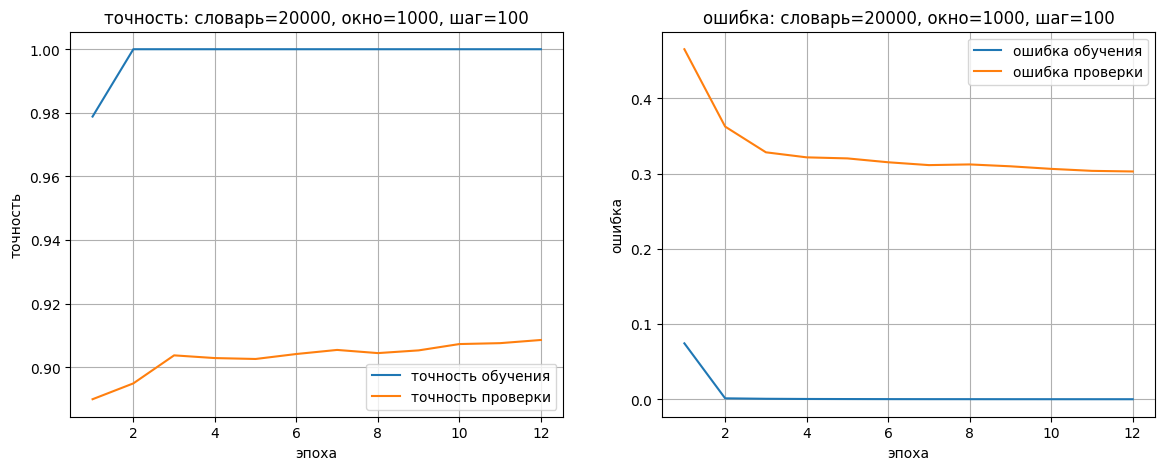


модель 8 из 9
словарь=20000, окно=1500, шаг=250
VOCAB_SIZE: 20000
WIN_SIZE: 1500
WIN_HOP: 250
x_train_bow: (7391, 20000)
y_train: (7391, 6)
x_test_bow: (2802, 20000)
y_test: (2802, 6)
Epoch 1/12
58/58 ━━━━━━━━━━━━━━━━━━━━ 9s 91ms/step - accuracy: 0.9572 - loss: 0.1553 - val_accuracy: 0.8012 - val_loss: 0.6218
Epoch 2/12
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 1.0000 - loss: 0.0032 - val_accuracy: 0.9008 - val_loss: 0.3950
Epoch 3/12
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 1.0000 - loss: 0.0017 - val_accuracy: 0.9183 - val_loss: 0.3216
Epoch 4/12
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 1.0000 - loss: 0.0011 - val_accuracy: 0.9197 - val_loss: 0.2946
Epoch 5/12
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 1.0000 - loss: 7.0714e-04 - val_accuracy: 0.9165 - val_loss: 0.2836
Epoch 6/12
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 1.0000 - loss: 6.0832e-04 - val_accuracy: 0.9147 - val_loss: 0.2777
Epoch 7/12
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms

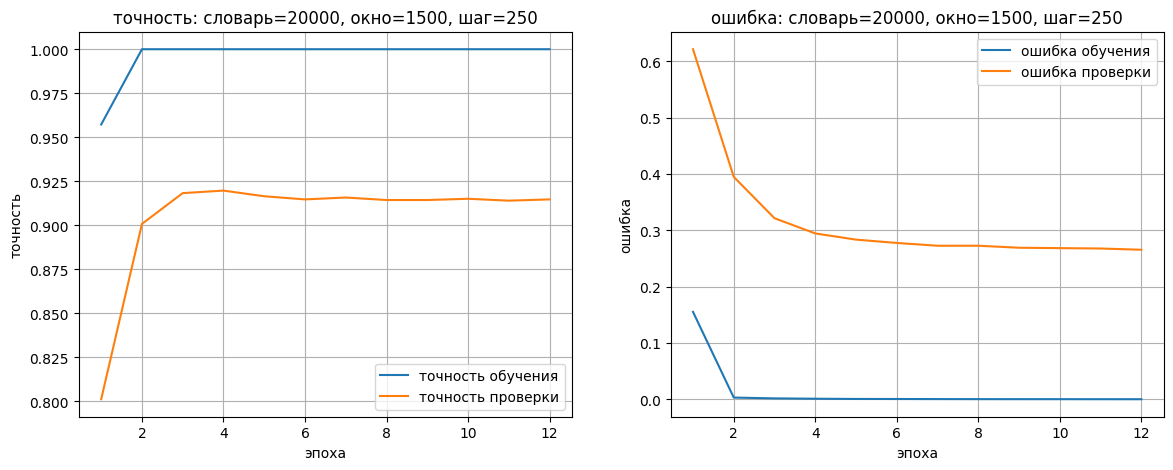


модель 9 из 9
словарь=20000, окно=2000, шаг=500
VOCAB_SIZE: 20000
WIN_SIZE: 2000
WIN_HOP: 500
x_train_bow: (3691, 20000)
y_train: (3691, 6)
x_test_bow: (1396, 20000)
y_test: (1396, 6)
Epoch 1/12
29/29 ━━━━━━━━━━━━━━━━━━━━ 8s 138ms/step - accuracy: 0.9228 - loss: 0.2682 - val_accuracy: 0.6325 - val_loss: 1.1006
Epoch 2/12
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 1.0000 - loss: 0.0076 - val_accuracy: 0.7385 - val_loss: 0.7776
Epoch 3/12
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 1.0000 - loss: 0.0032 - val_accuracy: 0.8080 - val_loss: 0.5820
Epoch 4/12
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 1.0000 - loss: 0.0025 - val_accuracy: 0.8517 - val_loss: 0.4663
Epoch 5/12
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 1.0000 - loss: 0.0018 - val_accuracy: 0.8890 - val_loss: 0.3977
Epoch 6/12
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 1.0000 - loss: 0.0013 - val_accuracy: 0.9026 - val_loss: 0.3572
Epoch 7/12
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step -

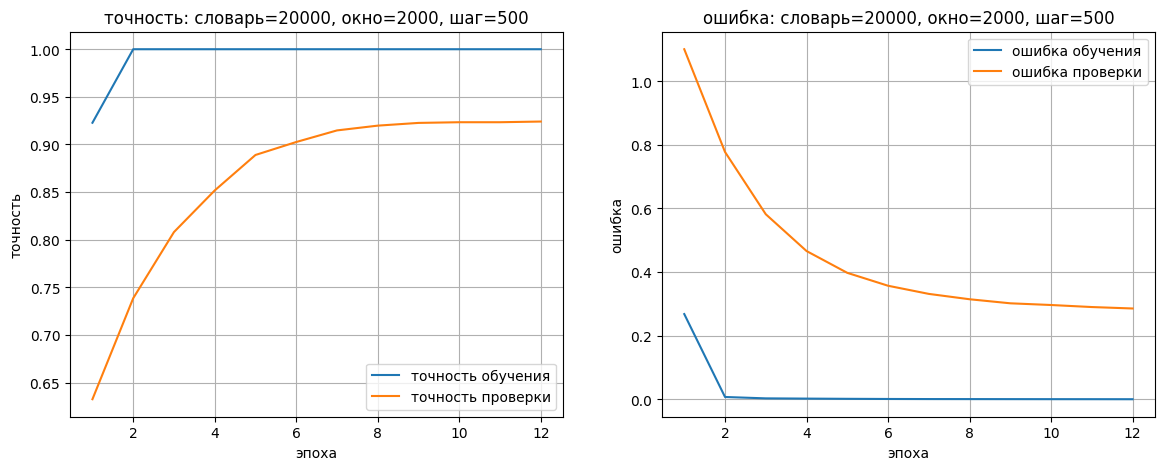

Время выполнения, сек.: 363.26


In [5]:
# список параметров для 9 моделей
params = [
    (10000, 1000, 100),
    (10000, 1500, 250),
    (10000, 2000, 500),
    (15000, 1000, 100),
    (15000, 1500, 250),
    (15000, 2000, 500),
    (20000, 1000, 100),
    (20000, 1500, 250),
    (20000, 2000, 500),
]

results = []
histories = []

EPOCHS = 12
BATCH_SIZE = 128

start_time = time.time()

for number, (vocab_size, win_size, win_hop) in enumerate(params, start=1):
    print('\n' + '=' * 80)
    print(f'модель {number} из {len(params)}')
    print(f'словарь={vocab_size}, окно={win_size}, шаг={win_hop}')
    print('=' * 80)

    result, history = run_experiment(
        vocab_size=vocab_size,
        win_size=win_size,
        win_hop=win_hop,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE
    )

    results.append(result)
    histories.append({
        'label': f'{vocab_size}, {win_size}, {win_hop}',
        'history': history.history
    })

print('Время выполнения, сек.:', round(time.time() - start_time, 2))


In [6]:
# итоговая таблица
results_df = pd.DataFrame(results)
results_df = results_df.sort_values('Лучшая точность на проверке', ascending=False).reset_index(drop=True)

display(results_df)

best_row = results_df.iloc[0]
print('Лучшая модель:')
print('VOCAB_SIZE:', best_row['VOCAB_SIZE'])
print('WIN_SIZE:', best_row['WIN_SIZE'])
print('WIN_HOP:', best_row['WIN_HOP'])
print('Лучшая точность на проверке:', round(best_row['Лучшая точность на проверке'], 4))
print('Лучшая ошибка на проверке:', round(best_row['Лучшая ошибка на проверке'], 4))


,VOCAB_SIZE,WIN_SIZE,WIN_HOP,Точность на обучении,Точность на проверке,Лучшая точность на проверке,Ошибка на обучении,Ошибка на проверке,Лучшая ошибка на проверке
0,15000,1500,250,1.0,0.925767,0.929693,0.000210,0.239524,0.239524
1,20000,2000,500,1.0,0.924069,0.924069,0.000536,0.285716,0.285716
2,20000,1500,250,1.0,0.914704,0.919700,0.000229,0.265654,0.265654
3,10000,1500,250,1.0,0.916488,0.918630,0.000293,0.254054,0.254054
4,10000,2000,500,1.0,0.916189,0.916189,0.000642,0.292868,0.292868
5,20000,1000,100,1.0,0.908548,0.908548,0.000060,0.302789,0.302789
6,10000,1000,100,1.0,0.900156,0.900583,0.000090,0.298062,0.298062
7,15000,2000,500,1.0,0.897564,0.897564,0.000519,0.322191,0.322191
8,15000,1000,100,1.0,0.894610,0.894610,0.000065,0.320325,0.320325


Лучшая модель:
VOCAB_SIZE: 15000.0
WIN_SIZE: 1500.0
WIN_HOP: 250.0
Лучшая точность на проверке: 0.9297
Лучшая ошибка на проверке: 0.2395
